In [1]:
import os
import sys
import json
import csv
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
import geopandas as gpd
import h3
import h3pandas

from shapely import wkt
from shapely.geometry import shape, Polygon
from shapely.geometry.polygon import orient
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
# Get the parent directory of the current directory (which is 'notebooks')
# and add it to the system path
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can use absolute imports from the project root
from utils.geometry import get_bearing, get_bearing_label, convert_geometry

In [4]:
import warnings
warnings.filterwarnings('ignore')

### Geo Admin boundaries

In [7]:
THRESHOLD_OVERLAP = 0.5

In [8]:
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")

In [9]:
data_fn = os.path.join(DATA_DIR, 'census\\tl_2024_us_aiannh\\tl_2024_us_aiannh.shp')

In [10]:
aiannh_gdf = gpd.read_file(data_fn)

<Axes: >

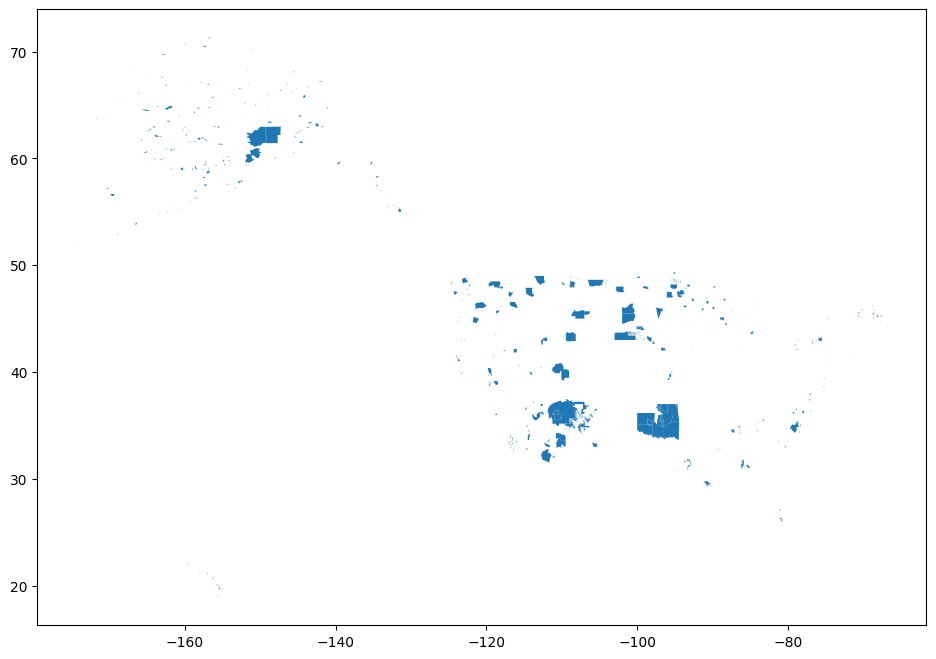

In [11]:
aiannh_gdf.plot(figsize=(13,8))

#### Create a 10km buffer for safety

In [12]:
aiannh_gdf = aiannh_gdf.to_crs(3857)

In [13]:
# aiannh_gdf['geom_buff'] = aiannh_gdf.buffer(10000)  # outer bounds 10km
aiannh_gdf['geom_buff'] = aiannh_gdf.buffer(5000)  # inner bounds  5km

In [14]:
aiannh_gdf['geometry'] = aiannh_gdf['geom_buff']

In [15]:
del aiannh_gdf['geom_buff']

In [16]:
# buffered_gdf = gpd.GeoDataFrame(geometry=buffered_mil, crs='EPSG:3857')

In [17]:
aiannh_gdf = aiannh_gdf.to_crs(4326)

In [18]:
# buffered_gdf.plot(figsize=(13, 8))

In [19]:
aiannh_gdf

,AIANNHCE,AIANNHNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,COMPTYP,AIANNHR,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,2320,02419022,2320R,2520000US2320R,Mohegan,Mohegan Reservation,86,D2,R,F,G2101,A,2457041,123,+41.4858024,-072.0902766,"POLYGON ((-72.15593 41.46047, -72.15713 41.463..."
1,9100,01930930,9100R,2520000US9100R,Golden Hill Paugussett,Golden Hill Paugussett (state) Reservation,86,D4,R,S,G2101,A,399343,0,+41.5521875,-072.2680204,"MULTIPOLYGON (((-72.31392 41.55178, -72.31408 ..."
2,4110,02419484,4110R,2520000US4110R,Table Mountain,Table Mountain Rancheria,85,D8,R,F,G2101,A,371387,0,+36.9850490,-119.6396814,"POLYGON ((-119.68531 36.98994, -119.68497 36.9..."
3,1380,01666180,1380R,2520000US1380R,Greenville,Greenville Rancheria,85,D2,R,F,G2101,A,284692,0,+40.1487839,-120.8933989,"POLYGON ((-120.94227 40.1516, -120.94197 40.15..."
4,1110,00806894,1110R,2520000US1110R,Flathead,Flathead Reservation,86,D2,R,F,G2101,A,5013467061,316267874,+47.4967703,-114.2842791,"POLYGON ((-114.86688 47.8581, -114.86705 47.85..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,5970,02418712,5970R,2520000US5970R,Miami/Peoria,Miami/Peoria joint-use OTSA,90,D0,R,F,G2170,S,32248316,439829,+36.9014538,-094.9203738,"POLYGON ((-95.00801 36.92123, -95.00764 36.925..."
860,5955,02418655,5955R,2520000US5955R,Kiowa-Comanche-Apache-Ft Sill Apache/Caddo-Wic...,Kiowa-Comanche-Apache-Ft Sill Apache/Caddo-Wic...,90,D0,R,F,G2170,S,499488939,1557225,+35.0575938,-098.3176096,"POLYGON ((-98.66571 35.0414, -98.66571 35.0437..."
861,4910,02418987,4910R,2520000US4910R,Kickapoo (KS) Reservation/Sac and Fox Nation T...,Kickapoo (KS) Reservation/Sac and Fox Nation T...,83,D0,R,F,G2170,A,1060454,0,+39.7010141,-095.7209027,"POLYGON ((-95.77295 39.70498, -95.77273 39.708..."
862,4930,02419124,4930R,2520000US4930R,San Felipe Pueblo/Santa Ana Pueblo,San Felipe Pueblo/Santa Ana Pueblo joint-use area,83,D0,R,F,G2170,A,2785129,0,+35.3627291,-106.4945407,"POLYGON ((-106.55794 35.36594, -106.557 35.369..."


### H3

In [20]:
native_hex_ids_r11 = []
native_hex_ids_r5 = []

In [21]:
try:
    tmp_hex_r5_df = aiannh_gdf.h3.polyfill(5, explode=True)
    native_hex_ids_r5 +=  tmp_hex_r5_df.h3_polyfill.drop_duplicates().to_list()
    
except Exception as e:
    print(e)
    print("error with r5")

In [22]:
h5_remove_list = [x for x in list(set(native_hex_ids_r5)) if str(x) != 'nan']

In [23]:
len(h5_remove_list)

2766

In [25]:
save_df = pd.DataFrame([{"hex_id": x, "reason": "native_land"} for x in h5_remove_list])

In [26]:
# save_df.to_csv('remove_hexes_r5_native_land_inner.csv')

In [27]:
hex_aiannh_df = save_df.copy()

In [28]:
hex_aiannh_df = hex_aiannh_df.set_index('hex_id')

In [29]:
hex_aiannh_df = hex_aiannh_df.h3.h3_to_geo_boundary()

In [30]:
hex_aiannh_df = hex_aiannh_df.h3.cell_area(unit='km^2')

In [31]:
hex_aiannh_df

,reason,geometry,h3_cell_area
hex_id,,,
85262277fffffff,native_land,"POLYGON ((-97.10798 45.28835, -97.18747 45.221...",256.881679
8548dd07fffffff,native_land,"POLYGON ((-107.6035 34.98865, -107.53878 35.06...",289.793595
8526eab3fffffff,native_land,"POLYGON ((-95.78145 35.66301, -95.71079 35.733...",272.940036
85288d2ffffffff,native_land,"POLYGON ((-120.37872 46.08884, -120.31896 46.1...",233.791992
8512da37fffffff,native_land,"POLYGON ((-118.13214 48.07659, -118.06835 48.1...",227.519929
...,...,...,...
8544492ffffffff,native_land,"POLYGON ((-94.4474 34.56099, -94.37717 34.6306...",272.422861
8526b55bfffffff,native_land,"POLYGON ((-108.78941 43.25461, -108.72021 43.3...",258.621100
850c720ffffffff,native_land,"POLYGON ((-151.76256 61.97752, -151.88725 61.9...",228.069132


In [32]:
hex_aiannh_df.reset_index(inplace=True)

In [33]:
hex_aiannh_overlap_gdf = gpd.overlay(hex_aiannh_df,\
                               aiannh_gdf[['NAME', 'GEOID', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']],\
                               how="intersection",\
                               keep_geom_type=False\
                              )

In [34]:
hex_aiannh_overlap_gdf

,hex_id,reason,h3_cell_area,NAME,GEOID,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,85262277fffffff,native_land,256.881679,Lake Traverse,1860R,3753377641,153531502,+45.6436354,-097.0923712,"POLYGON ((-97.13942 45.13832, -97.18747 45.221..."
1,8548dd07fffffff,native_land,289.793595,Laguna,1840R,1986973002,2068014,+35.0270287,-107.2347466,"POLYGON ((-107.59086 35.15142, -107.53878 35.0..."
2,8548dd07fffffff,native_land,289.793595,Acoma,0010R,1069592709,331928,+34.8667707,-107.6888783,"POLYGON ((-107.53878 35.06702, -107.6035 34.98..."
3,8548dd07fffffff,native_land,289.793595,Acoma,0010T,491297765,94718,+34.6058817,-107.6776487,"POLYGON ((-107.70777 35.15742, -107.60632 35.1..."
4,8526eab3fffffff,native_land,272.940036,Creek,5620R,11988117611,406112856,+35.6675677,-096.0182551,"POLYGON ((-95.8936 35.68004, -95.93524 35.7671..."
...,...,...,...,...,...,...,...,...,...,...
3865,8544492ffffffff,native_land,272.422861,Choctaw,5590R,27534663392,733623634,+34.5090320,-095.4434638,"POLYGON ((-94.4474 34.56099, -94.55731 34.5789..."
3866,8526b55bfffffff,native_land,258.621100,Wind River,4610R,8978352500,150318742,+43.2723824,-108.8444961,"POLYGON ((-108.91593 43.25897, -108.97344 43.3..."
3867,850c720ffffffff,native_land,228.069132,Knik,6785R,18094155590,980992646,+62.0546111,-150.3354418,"POLYGON ((-151.76256 61.97752, -151.58414 61.9..."
3868,8526c06ffffffff,native_land,280.583746,Cheyenne and Arapaho,5560R,21022187658,154026718,+35.6882710,-098.9538252,"POLYGON ((-99.08433 35.30681, -99.12904 35.393..."


In [35]:
hex_aiannh_overlap_gdf["overlap_area_m"] = hex_aiannh_overlap_gdf.to_crs(crs="EPSG:6933").geometry.area

In [36]:
hex_aiannh_overlap_gdf["overlap_area"] = hex_aiannh_overlap_gdf["overlap_area_m"] / 1e6

In [37]:
hex_aiannh_overlap_gdf["overlap_pct"] = hex_aiannh_overlap_gdf["overlap_area"] / hex_aiannh_overlap_gdf["h3_cell_area"]

In [38]:
hex_aiannh_80pct_gdf = hex_aiannh_overlap_gdf[(hex_aiannh_overlap_gdf["overlap_pct"] > 0.8)]

In [39]:
hex_aiannh_80pct_df = hex_aiannh_80pct_gdf.filter(['hex_id', 'reason', 'overlap_pct'])

In [40]:
hex_aiannh_80pct_df = hex_aiannh_80pct_df.rename(columns={'reason': 'reason_inhibited'})

In [41]:
hex_aiannh_80pct_df['is_inhibited'] = True

In [42]:
hex_aiannh_80pct_df = hex_aiannh_80pct_df.drop_duplicates(subset=["hex_id"])

In [43]:
hex_aiannh_80pct_df = hex_aiannh_80pct_df.reset_index(drop=True)

In [44]:
hex_aiannh_80pct_df

,hex_id,reason_inhibited,overlap_pct,is_inhibited
0,8548dd07fffffff,native_land,0.806745,True
1,8526eab3fffffff,native_land,1.000095,True
2,85288d2ffffffff,native_land,1.002500,True
3,8526b083fffffff,native_land,1.001804,True
4,85299643fffffff,native_land,1.000350,True
...,...,...,...,...
1896,852816d7fffffff,native_land,1.001095,True
1897,850c7207fffffff,native_land,1.005993,True
1898,8544492ffffffff,native_land,0.927272,True
1899,8526b55bfffffff,native_land,1.001836,True


In [45]:
save_fn = f"remove_hexes_h5_aiannh_{str(int(100*THRESHOLD_OVERLAP))}pct.csv"
save_sql = f"remove_hexes_h5_aiannh_{str(int(100*THRESHOLD_OVERLAP))}pct.sql"

In [46]:
print(f"INPUT: {save_fn}\tOUTPUT: {save_sql}")

INPUT: remove_hexes_h5_aiannh_50pct.csv	OUTPUT: remove_hexes_h5_aiannh_50pct.sql


In [47]:
hex_aiannh_80pct_df.to_csv(save_fn)

In [48]:
import csv

# --- Configuration ---
# INPUT_FILE = 'C:/Users/bcros/dev/blcrosbie/GeoDataAnalytics/notebooks/remove_hexes_h5_aiannh_80pct.csv'
# INPUT_FILE = 'C:/Users/bcros/dev/blcrosbie/GeoDataAnalytics/notebooks/remove_hexes_h5_mil_80pct.csv'
# INPUT_FILE = 'C:/Users/bcros/dev/blcrosbie/GeoDataAnalytics/notebooks/remove_hexes_r5_native_land.csv'
INPUT_FILE = f'C:/Users/bcros/dev/blcrosbie/GeoDataAnalytics/notebooks/{save_fn}'
# OUTPUT_FILE = 'bulk_update_native_land.sql'
OUTPUT_FILE = save_sql
# OUTPUT_FILE = 'bulk_update_native_land.sql'
# OUTPUT_FILE = 'remove_hexes_h5_mil_80pct.sql'
# OUTPUT_FILE = 'remove_hexes_h5_aiannh_80pct.sql'
TABLE_NAME = 'public.hexes'
# The column name we are setting the boolean flag on
INHIBITED_COLUMN = 'is_inhibited'
# The column name we are setting the reason on
REASON_COLUMN = 'reason_inhibited'
# The column used for the WHERE clause
KEY_COLUMN = 'hex_id'
# --- End Configuration ---


def generate_sql_updates():
    """Reads CSV data and generates a series of SQL UPDATE statements."""
    sql_statements = []

    try:
        with open(INPUT_FILE, mode='r', newline='', encoding='utf-8') as infile:
            # Use DictReader to read data using column headers
            reader = csv.DictReader(infile)
            
            for row in reader:
                hex_id = row.get(KEY_COLUMN)
                reason = row.get('reason_inhibited')

                if not hex_id or not reason:
                    print(f"Skipping row due to missing data: {row}")
                    continue

                # Ensure values are properly quoted for SQL insertion
                # Text values (reason) must be surrounded by single quotes
                # If reason contains a single quote, it needs to be escaped (doubled up)
                safe_reason = reason.replace("'", "''")

                # The SQL UPDATE statement structure
                sql = f"""
UPDATE {TABLE_NAME}
SET 
    {INHIBITED_COLUMN} = TRUE,
    {REASON_COLUMN} = '{safe_reason}'
WHERE 
    {KEY_COLUMN} = '{hex_id}';
"""
                sql_statements.append(sql.strip())

    except FileNotFoundError:
        print(f"Error: Input file '{INPUT_FILE}' not found. Please create it.")
        return []
    except Exception as e:
        print(f"An error occurred during CSV reading: {e}")
        return []

    # Format the statements into a safe transaction block
    full_sql_output = [
        "-- --- Generated SQL Bulk Update Script ---",
        f"-- Generated from {INPUT_FILE} at {len(sql_statements)} rows.",
        "BEGIN;",
        *sql_statements,
        "COMMIT;",
        "-- --- End of Script ---"
    ]

    return full_sql_output


# --- Main Execution ---
generated_sql = generate_sql_updates()

if generated_sql:
    try:
        with open(OUTPUT_FILE, 'w', encoding='utf-8') as outfile:
            outfile.write('\n'.join(generated_sql))
        print(f"\nSuccessfully generated {len(generated_sql) - 4} SQL UPDATE statements.")
        print(f"Output saved to '{OUTPUT_FILE}'.")
        print("\nRun this file against your PostgreSQL database to apply changes.")
    except Exception as e:
        print(f"An error occurred during file writing: {e}")


Successfully generated 1902 SQL UPDATE statements.
Output saved to 'remove_hexes_h5_aiannh_50pct.sql'.

Run this file against your PostgreSQL database to apply changes.


In [27]:
# try:
#     tmp_hex_r11_df = aiannh_gdf.h3.polyfill(11, explode=True)
#     military_hex_ids_r11 += tmp_hex_r11_df.h3_polyfill.drop_duplicates().to_list()
    
# except Exception as e:
#     print(e)
#     print("error with r11")

In [33]:
h11_remove_list = [x for x in list(set(military_hex_ids_r11)) if str(x) != 'nan']

In [34]:
len(h11_remove_list)

48261288

In [35]:
save_df = pd.DataFrame([{"hex_id": x, "reason": "native_land"} for x in h11_remove_list])
save_df.to_csv('remove_hexes_r11_military.csv')

#### Output

In [86]:
def hex_polygon(hex_id):
    """
    Return shapely Polygon of an H3 cell in lon/lat (EPSG:4326).

    Works with older h3-py that returns (lat, lng) and does NOT support geo_json.
    """
    boundary = h3.cell_to_boundary(hex_id)  # list of (lat, lng)
    # convert to (lon, lat) for shapely / mercantile
    coords = [(lng, lat) for lat, lng in boundary]
    poly = Polygon(coords)
    # Normalize orientation (CCW) just to be consistent
    return orient(poly, sign=1.0)

In [128]:
# --- 3. Create a Pandas DataFrame ---
removal_df = pd.DataFrame({'hex_id': h5_remove_list})
print(f"Converting {len(removal_df)} H3 IDs to polygon geometries...")
removal_df['geometry'] = removal_df['hex_id'].apply(hex_polygon)

Converting 726 H3 IDs to polygon geometries...


In [129]:
# --- 5. Create the GeoDataFrame ---
# Use EPSG:4326 (WGS 84) which is the standard CRS for H3.
gdf = gpd.GeoDataFrame(removal_df, geometry='geometry', crs="EPSG:4326")

In [131]:
# --- 6. Save the GeoDataFrame to a File ---
output_file = 'hex_native_land_validation_r5_inner.geojson'

# GeoJSON is generally the most compatible and robust format for sharing.
# For a shapefile, you would use: gdf.to_file('h3_coverage_validation.shp')
try:
    gdf.to_file(output_file, driver='GeoJSON')
    print("-" * 50)
    print(f"Successfully created GeoJSON file: {output_file}")
    print(f"File saved with {len(gdf)} features.")
    print("You can now load this file into QGIS to visualize your H3 coverage areas.")
except Exception as e:
    print(f"Error saving file: {e}")

# Display a preview of the GeoDataFrame structure
print("\nGeoDataFrame Preview:")
print(gdf.head())

--------------------------------------------------
Successfully created GeoJSON file: hex_military_zone_validation_r5_inner.geojson
File saved with 726 features.
You can now load this file into QGIS to visualize your H3 coverage areas.

GeoDataFrame Preview:
            hex_id                                           geometry
0  85299a73fffffff  POLYGON ((-113.24179 40.33158, -113.17835 40.4...
1  85298387fffffff  POLYGON ((-116.34067 37.53534, -116.28181 37.6...
2  8526963bfffffff  POLYGON ((-111.95341 40.40339, -111.88877 40.4...
3  85444c33fffffff  POLYGON ((-93.69238 32.39516, -93.62339 32.465...
4  852a1313fffffff  POLYGON ((-74.37894 40.15285, -74.48026 40.106...


In [80]:
# --- 3. Create a Pandas DataFrame ---
removal_11_df = pd.DataFrame({'hex_id': h11_remove_list})
print(f"Converting {len(removal_11_df)} H3 IDs to polygon geometries...")
removal_11_df['geometry'] = removal_11_df['hex_id'].apply(hex_polygon)

KeyboardInterrupt: 

In [ ]:
# --- 5. Create the GeoDataFrame ---
# Use EPSG:4326 (WGS 84) which is the standard CRS for H3.
gdf_11 = gpd.GeoDataFrame(removal_11_df, geometry='geometry', crs="EPSG:4326")

In [ ]:
# --- 6. Save the GeoDataFrame to a File ---
output_file = 'hex_native_land_validation_r11.geojson'

# GeoJSON is generally the most compatible and robust format for sharing.
# For a shapefile, you would use: gdf.to_file('h3_coverage_validation.shp')
try:
    gdf_11.to_file(output_file, driver='GeoJSON')
    print("-" * 50)
    print(f"Successfully created GeoJSON file: {output_file}")
    print(f"File saved with {len(gdf_11)} features.")
    print("You can now load this file into QGIS to visualize your H3 coverage areas.")
except Exception as e:
    print(f"Error saving file: {e}")

# Display a preview of the GeoDataFrame structure
print("\nGeoDataFrame Preview:")
print(gdf_11.head())

#### Native Lands

In [41]:
data_fn = os.path.join(DATA_DIR, 'census\\tl_2024_us_aiannh\\tl_2024_us_aiannh.shp')

In [42]:
nl_gdf = gpd.read_file(data_fn)

<Axes: >

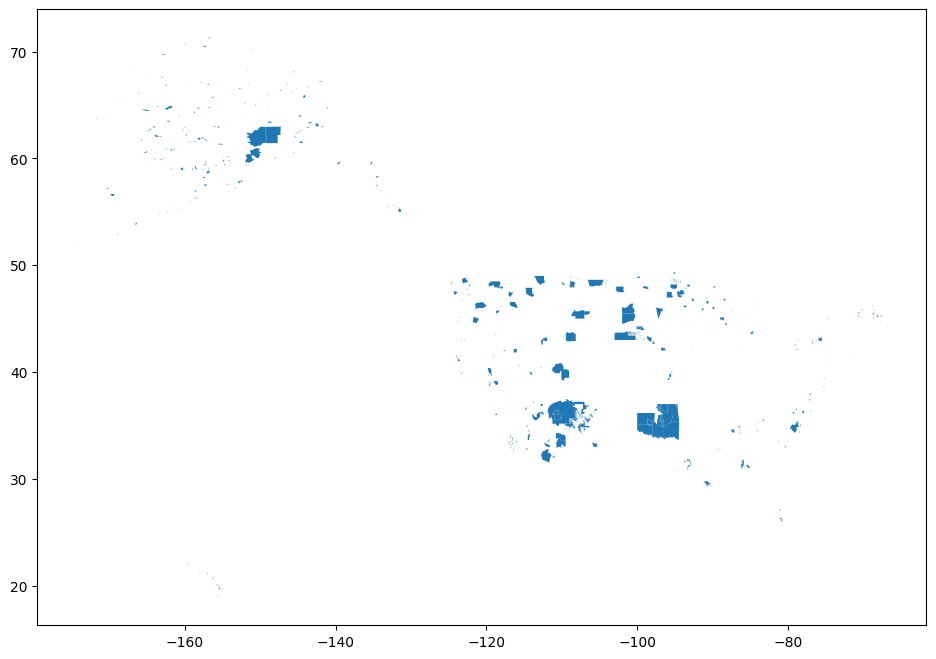

In [43]:
nl_gdf.plot(figsize=(13,8))

In [44]:
nl_gdf = nl_gdf.to_crs(3857)

In [47]:
nl_gdf['geom_buff'] = nl_gdf.buffer(10000)

In [48]:
nl_gdf['geometry'] = nl_gdf['geom_buff']

In [49]:
del nl_gdf['geom_buff']

In [50]:
nl_gdf = nl_gdf.to_crs(4326)

In [51]:
nl_hex_ids_r5 = []

In [52]:
try:
    tmp_hex_r5_df = nl_gdf.h3.polyfill(5, explode=True)
    nl_hex_ids_r5 +=  tmp_hex_r5_df.h3_polyfill.drop_duplicates().to_list()
    
except Exception as e:
    print(e)
    print("error with r5")

In [53]:
h5_remove_list = [x for x in list(set(nl_hex_ids_r5)) if str(x) != 'nan']

In [54]:
len(h5_remove_list)

3667

In [55]:
save_df = pd.DataFrame([{"hex_id": x, "reason": "native_land"} for x in h5_remove_list])

In [56]:
save_df.to_csv('remove_hexes_r5_native_land.csv')

In [57]:
# --- 3. Create a Pandas DataFrame ---
removal_df = pd.DataFrame({'hex_id': h5_remove_list})
print(f"Converting {len(removal_df)} H3 IDs to polygon geometries...")
removal_df['geometry'] = removal_df['hex_id'].apply(hex_polygon)

Converting 3667 H3 IDs to polygon geometries...


In [58]:
# --- 5. Create the GeoDataFrame ---
# Use EPSG:4326 (WGS 84) which is the standard CRS for H3.
gdf = gpd.GeoDataFrame(removal_df, geometry='geometry', crs="EPSG:4326")

In [59]:
# --- 6. Save the GeoDataFrame to a File ---
output_file = 'hex_native_land_validation_r5.geojson'

# GeoJSON is generally the most compatible and robust format for sharing.
# For a shapefile, you would use: gdf.to_file('h3_coverage_validation.shp')
try:
    gdf.to_file(output_file, driver='GeoJSON')
    print("-" * 50)
    print(f"Successfully created GeoJSON file: {output_file}")
    print(f"File saved with {len(gdf)} features.")
    print("You can now load this file into QGIS to visualize your H3 coverage areas.")
except Exception as e:
    print(f"Error saving file: {e}")

# Display a preview of the GeoDataFrame structure
print("\nGeoDataFrame Preview:")
print(gdf.head())

--------------------------------------------------
Successfully created GeoJSON file: hex_native_land_validation_r5.geojson
File saved with 3667 features.
You can now load this file into QGIS to visualize your H3 coverage areas.

GeoDataFrame Preview:
            hex_id                                           geometry
0  85260bc7fffffff  POLYGON ((-95.6315 40.09126, -95.55773 40.1578...
1  85269187fffffff  POLYGON ((-109.22882 39.79449, -109.16233 39.8...
2  8548e9cbfffffff  POLYGON ((-111.90989 32.50821, -111.84976 32.5...
3  8529b3cffffffff  POLYGON ((-113.19913 35.47418, -113.1385 35.55...
4  8548dd8bfffffff  POLYGON ((-107.46049 34.57181, -107.39591 34.6...
